# Fetch cryptocurrency off-chain data via the Coinbase Exchange API

## Dependencies
- Install the `requests`, `pandas`, and `matplotlib` libraries using the following command:
```bash
pip install --upgrade pip
pip install requests pandas matplotlib
```

In [1]:
from datetime import datetime, timedelta, timezone
from time import sleep
from typing import Optional
from urllib.parse import quote

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests

## Open, High, Low, Close, and Volume (OHLCV) data

### What is OHLCV data
OHLCV is an aggregated form of market data standing for Open, High, Low, Close and Volume. OHLCV data includes 5 data points: the Open and Close represent the first and the last price level during a specified interval. High and Low represent the highest and lowest reached price during that interval. Volume is the total amount traded during that period. This data is most frequently represented in a candlestick chart, which allows traders to perform technical analysis on intraday values. We provide OHLCV data with daily granularity.

### Why we need to fetch OHLCV data
- Quantitative trading: OHLCV data is the most basic and widely used data for quantitative trading. It is used to create trading strategies, backtesting, and risk management.
- Research: OHLCV data is used for research purposes such as empirical asset pricing, scam detection, and market efficiency.
- Technical analysis: OHLCV data is used to create candlestick charts, which are used to identify patterns and trends in the market.


<img src="./fig/candlestick.ppm" width="800">

## Coinbase Exchange

### What is Coinbase Exchange
[Coinbase Exchange](https://www.coinbase.com/exchange) is a cryptocurrency exchange. Its public market-data API provides historical OHLCV candles for listed trading pairs such as BTC-USD and ETH-USD. This lab uses public endpoints, so no account or API key is needed.

### Step 1: Try a public API request
Read the [Get product candles documentation](https://docs.cdp.coinbase.com/api-reference/exchange-api/rest-api/products/get-product-candles), then open this URL in a browser:


https://api.exchange.coinbase.com/products/BTC-USD/candles?granularity=86400

- `BTC-USD` is the product ID: Bitcoin traded against US dollars.
- `granularity=86400` requests daily candles (86,400 seconds per day).
- Each candle is an array in this order: `[time, low, high, open, close, volume]`.
- `time` is the UTC bucket start in Unix seconds. `volume` is measured in the base asset (BTC for BTC-USD).
- The response can be in reverse time order and can include today's unfinished candle.

The following minimum working example checks the HTTP response and shows three candles.

In [2]:
response = requests.get(
    "https://api.exchange.coinbase.com/products/BTC-USD/candles",
    params={"granularity": 86400},
    timeout=60,
)
response.raise_for_status()
response.json()[:3]

[[1791158400, 84944.2, 86996, 86502.65, 85904.18, 5168.28113187],
 [1791072000, 84700.02, 86792.81, 84742.22, 86507.11, 2622.78236607],
 [1790985600, 84425.07, 85021.57, 84504.88, 84742.22, 1921.24898945]]

### Step 2: Fetch a longer history locally
We can turn the request into a reusable function:

- `fsym`: base asset, such as BTC or ETH.
- `tsym`: quote currency, such as USD. The pair must be listed on Coinbase Exchange.
- `start_date`: starting date in `YYYY-MM-DD` format (default: `2010-01-01`). The API returns only dates for which Coinbase has trading data.
- `limit`: optional number of completed UTC calendar days to look back over. The default `None` searches from `start_date` through yesterday. Set a positive integer for a shorter recent history. These are helper parameters, not Coinbase API query parameters.
- `start` and `end`: ISO 8601 timestamps that select each API request's time range.
- `granularity`: 86400 for daily candles.

Coinbase documents a maximum of 300 candles per request. We divide the range into windows of 299 days to allow for inclusive endpoints, filter out rows outside each window, deduplicate timestamps, and sort oldest first. We exclude today because its candle is still changing and pause briefly between requests to respect the [public API rate limit](https://docs.cdp.coinbase.com/exchange/rest-api/rate-limits).

The helper returns a list of dictionaries with `time`, `low`, `high`, `open`, `close`, and `volume`. HTTP errors are raised before attempting to parse candles.

In [3]:
def get_daily_pair_ohlcv(
    fsym: str,
    tsym: str = "USD",
    limit: Optional[int] = None,
    start_date: str = "2010-01-01",
) -> list[dict]:
    """Fetch available Coinbase daily history from start_date through yesterday.

    Only pairs listed on Coinbase Exchange are supported. No API key is needed.
    With limit=None, search from start_date (YYYY-MM-DD); dates before trading
    began return no candles. Set limit to a positive integer to fetch only the
    last limit completed UTC days instead.
    Return records with time (Unix seconds), low, high, open, close, and volume
    (in the base asset), sorted by time. Days without trades may be absent.
    """
    if limit is not None and (
        isinstance(limit, bool) or not isinstance(limit, int) or limit <= 0
    ):
        raise ValueError("limit must be a positive integer number of days.")
    fsym, tsym = fsym.strip().upper(), tsym.strip().upper()
    if not fsym or not tsym:
        raise ValueError("fsym and tsym must be non-empty currency symbols.")

    product_id = f"{fsym}-{tsym}"
    url = (
        "https://api.exchange.coinbase.com/products/"
        f"{quote(product_id, safe='')}/candles"
    )
    # Exclude today's candle because its OHLCV values are still changing.
    end = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
    if limit is None:
        start = datetime.strptime(start_date, "%Y-%m-%d").replace(tzinfo=timezone.utc)
        if start >= end:
            raise ValueError("start_date must be before today's UTC date.")
    else:
        start = end - timedelta(days=limit)
    cursor = start
    candles = {}

    with requests.Session() as session:
        while cursor < end:
            # 299 days leaves room for an inclusive endpoint (300 candles).
            batch_end = min(cursor + timedelta(days=299), end)
            response = session.get(
                url,
                params={
                    "granularity": 86400,
                    "start": cursor.isoformat(),
                    "end": batch_end.isoformat(),
                },
                timeout=60,
            )
            response.raise_for_status()
            batch = response.json()
            if not isinstance(batch, list):
                raise ValueError(
                    f"Unexpected Coinbase response for {product_id}: {batch}"
                )

            for candle in batch:
                if not isinstance(candle, list) or len(candle) != 6:
                    raise ValueError(f"Unexpected Coinbase candle: {candle}")
                timestamp = int(candle[0])
                # The API can return candles outside the requested batch.
                if cursor.timestamp() <= timestamp < batch_end.timestamp():
                    candles[timestamp] = {
                        "time": timestamp,
                        **dict(
                            zip(
                                ("low", "high", "open", "close", "volume"),
                                map(float, candle[1:]),
                            )
                        ),
                    }

            cursor = batch_end
            if cursor < end:
                sleep(0.2)

    if not candles:
        raise ValueError(
            f"No daily candles returned for {product_id} in the requested period."
        )
    return [candles[timestamp] for timestamp in sorted(candles)]

In [4]:
# Search from 2015 and fetch all available Coinbase BTC-USD daily history.
btc_json = get_daily_pair_ohlcv(fsym="BTC", tsym="USD", start_date="2015-07-20")

# Convert the normalized records into a pandas DataFrame.
btc_df = pd.DataFrame(btc_json)
btc_df["time"] = pd.to_datetime(btc_df["time"], unit="s", utc=True)

btc_df

,time,low,high,open,close,volume
0,2015-07-20 00:00:00+00:00,277.37,280.00,277.98,280.00,782.883420
1,2015-07-21 00:00:00+00:00,276.85,281.27,279.96,277.32,4943.559434
2,2015-07-22 00:00:00+00:00,275.01,278.54,277.33,277.89,4687.909383
3,2015-07-23 00:00:00+00:00,276.28,279.75,277.96,277.39,5306.919575
4,2015-07-24 00:00:00+00:00,276.43,291.52,277.23,289.12,7362.469083
...,...,...,...,...,...,...
4090,2026-09-30 00:00:00+00:00,82911.86,85613.72,83638.42,83556.14,7049.238750
4091,2026-10-01 00:00:00+00:00,83107.03,85244.00,83556.14,84848.73,6608.918694
4092,2026-10-02 00:00:00+00:00,83850.02,87249.05,84848.73,84504.88,8762.226186
4093,2026-10-03 00:00:00+00:00,84425.07,85021.57,84504.88,84742.22,1921.248989


### Step 3: Visualize the close price
The DataFrame is already ordered by time. Plot the daily close price in USD using matplotlib.

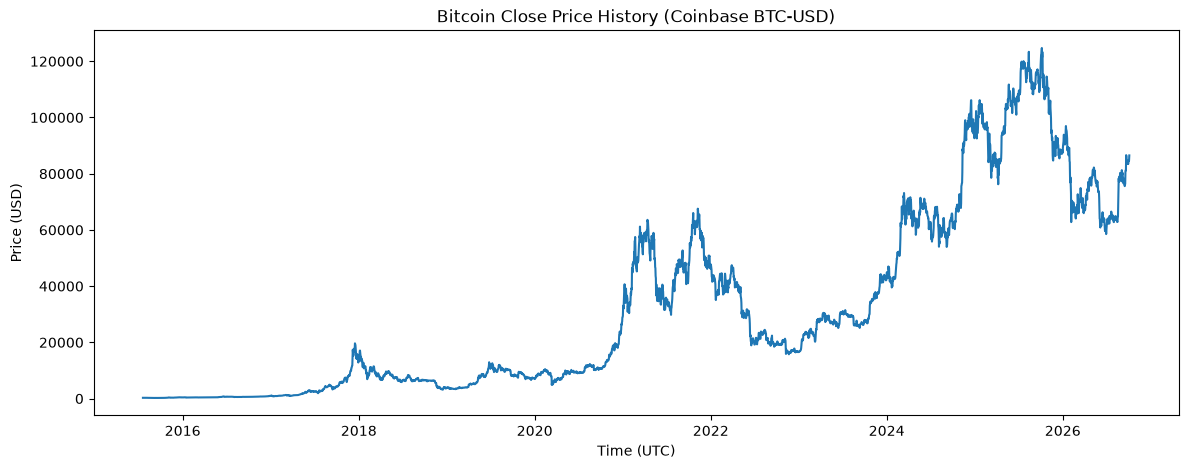

In [5]:
# Visualize the close price.
plt.figure(figsize=(14, 5))
plt.plot(btc_df["time"], btc_df["close"])
plt.xlabel("Time (UTC)")
plt.ylabel("Price (USD)")
plt.title("Bitcoin Close Price History (Coinbase BTC-USD)")
plt.show()

### Step 4: Draw candlesticks and trading volume

Use the same OHLCV records to draw a second figure: daily candlesticks above and trading volume below. Each wick spans the low and high; each body spans the open and close. Green means the close is at or above the open, and red means it is below the open.

We show the full available history, matching the close-price line chart. `candlestick_days=None` keeps every candle; set a positive integer to zoom in on recent days. Daily candles are densely packed over this long time range. Both panels share UTC dates; prices are in USD and volume is in BTC. This figure is drawn directly from the Coinbase data.

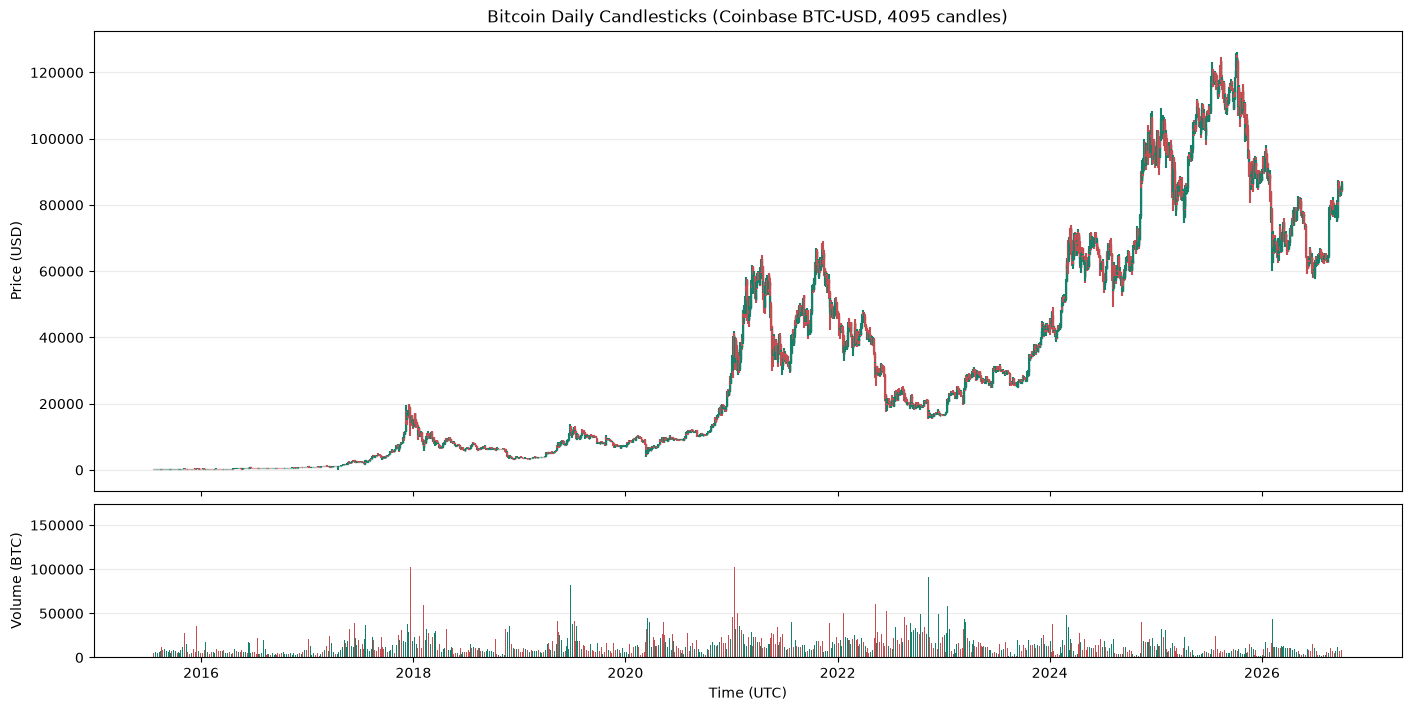

In [6]:
# Draw daily candlesticks and volume from the same Coinbase data.
# Show the full history on both figures; set an integer for a shorter window.
candlestick_days = None
chart_df = btc_df if candlestick_days is None else btc_df.tail(candlestick_days)
dates = mdates.date2num(chart_df["time"].tolist())
colors = [
    "#16816a" if close >= open_price else "#c44e52"
    for open_price, close in zip(chart_df["open"], chart_df["close"])
]

fig, (price_ax, volume_ax) = plt.subplots(
    2, 1, sharex=True, figsize=(14, 7),
    gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True,
)
# The wick spans low to high; the body spans open to close.
price_ax.vlines(dates, chart_df["low"], chart_df["high"], colors=colors)
price_ax.bar(
    dates, (chart_df["close"] - chart_df["open"]).abs(),
    bottom=chart_df[["open", "close"]].min(axis=1),
    width=0.6, color=colors, edgecolor=colors,
)
# Show a horizontal body when open and close are equal (a doji).
for date, open_price, close, color in zip(
    dates, chart_df["open"], chart_df["close"], colors
):
    if open_price == close:
        price_ax.hlines(open_price, date - 0.3, date + 0.3, color=color)

volume_ax.bar(dates, chart_df["volume"], width=0.6, color=colors)
price_ax.set_title(
    f"Bitcoin Daily Candlesticks (Coinbase BTC-USD, {len(chart_df)} candles)"
)
price_ax.set_ylabel("Price (USD)")
volume_ax.set_ylabel("Volume (BTC)")
volume_ax.set_xlabel("Time (UTC)")
locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
volume_ax.xaxis.set_major_locator(locator)
volume_ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
for ax in (price_ax, volume_ax):
    ax.grid(axis="y", alpha=0.25)
plt.show()